# Регрессия глубины дефектов (вариант B) — 2 эксперимента

Чистая регрессия: бэкбон → 1 нейрон, лосс **SmoothL1 (Huber)**, таргет — глубина
залегания в **мм**. Обучаемся только на дефектных кропах (локализацию на инференсе
даёт сегментация).

**Диапазоны глубин почти не пересекаются:** kaggle = 5–25 мм (5 дискретных),
tpu = 0.5–6.1 мм (непрерывно). Отсюда два эксперимента:

1. **Перенос:** train = kaggle, test = весь tpu (held-out домен). Честная оценка
   переноса, но tpu-диапазон для модели — экстраполяция вниз.
2. **Смесь:** train = kaggle + часть tpu-видео, test = held-out видео каждого
   домена, метрики раздельно. Смешение закрывает 0.5–25 мм → экстраполяция
   превращается в интерполяцию.

Метрики: `mae_mm`, `rmse_mm`, `r2` + дискретизированные `acc_quant`/`qwk_quant`
(предсказание → ближайший узел kaggle-сетки; осмысленно в основном на kaggle).

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))     # regression-experiments (config/main/...)
sys.path.insert(0, os.path.abspath("../.."))  # корень репо (пакет irt_data для аугментаций)
import numpy as np, torch
import matplotlib.pyplot as plt

import main as M
from config import CFG
from datasets import Modes
from metrics import RegressionMetrics

MODE = Modes.p5_d1
CFG.train.epochs = 50          # для ноутбука; в проде — 50/100
device = M.get_device()
print("device:", device, "| mode:", MODE.value, "| loss:", CFG.regression.loss_name,
      "| epochs:", CFG.train.epochs)

device: mps | mode: p5+d1 | loss: smooth_l1 | epochs: 50


In [6]:
# TSR-признаки (кэшируются один раз) + сборка индексов кропов
M.precompute_features()
M.precompute_tpu_features()

idx_kaggle = M.build_index_kaggle()
idx_tpu    = M.build_index_tpu()
print(f"кропов: kaggle={len(idx_kaggle)} | tpu={len(idx_tpu)}")
print("kaggle глубины, мм:", sorted(set(round(r[3],2) for r in idx_kaggle)))
print("tpu глубины, мм   :", sorted(set(round(r[3],2) for r in idx_tpu)))

кропов: kaggle=376 | tpu=160
kaggle глубины, мм: [5.0, 10.0, 15.0, 20.0, 25.0]
tpu глубины, мм   : [1.0, 1.5, 1.7, 1.9, 2.1, 2.2, 2.6, 3.1, 3.6, 3.8, 4.0, 4.2, 4.7, 5.2, 5.7, 5.9, 6.1]


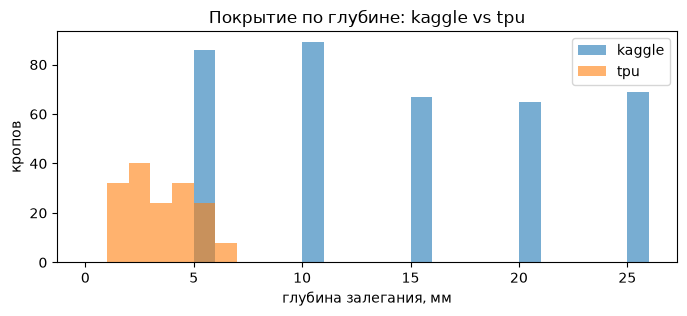

In [7]:
# Распределение таргета по доменам
fig, ax = plt.subplots(figsize=(8,3))
ax.hist([r[3] for r in idx_kaggle], bins=np.arange(0,27,1), alpha=.6, label="kaggle")
ax.hist([r[3] for r in idx_tpu],    bins=np.arange(0,27,1), alpha=.6, label="tpu")
ax.set_xlabel("глубина залегания, мм"); ax.set_ylabel("кропов"); ax.legend()
ax.set_title("Покрытие по глубине: kaggle vs tpu"); plt.show()

## Эксперимент 1 — перенос kaggle → tpu

Обучаем на всём kaggle, тестируем на всём tpu. Ожидаем заметную ошибку: tpu-глубины
(0.5–6 мм) лежат ниже kaggle-сетки (5–25 мм) — модель экстраполирует.

In [8]:
out1 = M.run(idx_kaggle, idx_tpu, mode=MODE, tag="exp1_kaggle2tpu", device=device)
metrics1 = out1["metrics"].by_domain()
metrics1

Current model: convnext_nano (pretrained=False)
Current model: RegressionModel (device=mps)
START tag=exp1_kaggle2tpu device=mps epochs=50 lr=0.001 params=14963441
epoch   1/50 | train_loss 1.75598 | val_mae 15.1591 мм | val_rmse 15.5919 мм
epoch   2/50 | train_loss 0.52881 | val_mae 9.2839 мм | val_rmse 9.7431 мм
epoch   3/50 | train_loss 0.41266 | val_mae 12.9130 мм | val_rmse 13.6876 мм
epoch   4/50 | train_loss 0.38054 | val_mae 11.8213 мм | val_rmse 12.5081 мм
epoch   5/50 | train_loss 0.34004 | val_mae 14.5099 мм | val_rmse 15.7157 мм
epoch   6/50 | train_loss 0.25674 | val_mae 13.6822 мм | val_rmse 15.2387 мм
epoch   7/50 | train_loss 0.22071 | val_mae 14.0095 мм | val_rmse 15.1674 мм
epoch   8/50 | train_loss 0.19741 | val_mae 14.5120 мм | val_rmse 15.9428 мм
epoch   9/50 | train_loss 0.17113 | val_mae 13.4828 мм | val_rmse 14.6275 мм
epoch  10/50 | train_loss 0.16795 | val_mae 14.3387 мм | val_rmse 15.5392 мм
epoch  11/50 | train_loss 0.14314 | val_mae 13.4369 мм | val_rmse 14

{'tpu': {'mae_mm': 13.811902531981469,
  'rmse_mm': 15.386620531089456,
  'medae_mm': 13.816559791564941,
  'bias_mm': 13.811902531981469,
  'r2': -99.00869879733868,
  'acc_quant': 0.025,
  'qwk_quant': 0.0},
 'all': {'mae_mm': 13.811902531981469,
  'rmse_mm': 15.386620531089456,
  'medae_mm': 13.816559791564941,
  'bias_mm': 13.811902531981469,
  'r2': -99.00869879733868,
  'acc_quant': 0.025,
  'qwk_quant': 0.0}}

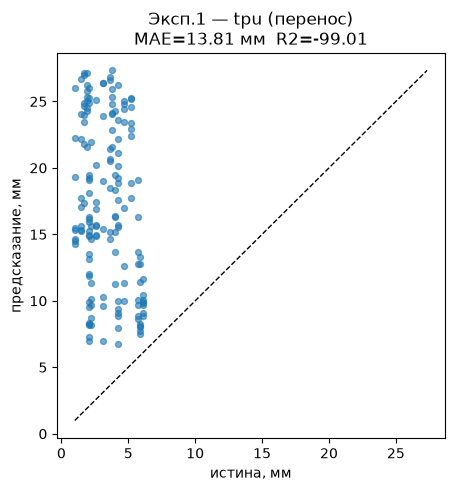

In [9]:
# pred vs true на tpu
def scatter_pred(rm, title):
    yt, yp = rm.y_true, rm.y_pred
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(yt, yp, s=18, alpha=.6)
    ax.plot([lo,hi],[lo,hi],"k--",lw=1)
    ax.set_xlabel("истина, мм"); ax.set_ylabel("предсказание, мм")
    m = rm.compute(); ax.set_title(f"{title}\nMAE={m['mae_mm']:.2f} мм  R2={m['r2']:.2f}")
    plt.show()

scatter_pred(out1["metrics"], "Эксп.1 — tpu (перенос)")

## Эксперимент 2 — смешанный трейн, раздельный тест

`train = kaggle + часть tpu-видео`, `test = held-out видео каждого домена`. Сплит
строго по видео (у tpu все дефекты одного видео на одной глубине → случайный сплит
= утечка). Метрики считаем раздельно по доменам.

In [10]:
combined = idx_kaggle + idx_tpu
# по 3 held-out видео из каждого домена в тест, остальное — в общий трейн
train_idx, test_idx = M.split_by_video(combined, n_test=3,
                                       domains=["kaggle","tpu"], seed=CFG.train.seed)
def dom_vids(idx, d): return sorted({r[0] for r in idx if r[4]==d})
print("train видео: kaggle=%d tpu=%d" % (len(dom_vids(train_idx,'kaggle')), len(dom_vids(train_idx,'tpu'))))
print("test  видео: kaggle=%d tpu=%d" % (len(dom_vids(test_idx,'kaggle')), len(dom_vids(test_idx,'tpu'))))
print("train кропов=%d test кропов=%d" % (len(train_idx), len(test_idx)))

train видео: kaggle=35 tpu=17
test  видео: kaggle=3 tpu=3
train кропов=492 test кропов=44


In [11]:
out2 = M.run(train_idx, test_idx, mode=MODE, tag="exp2_mixed", device=device)
metrics2 = out2["metrics"].by_domain()
metrics2

Current model: convnext_nano (pretrained=False)
Current model: RegressionModel (device=mps)
START tag=exp2_mixed device=mps epochs=50 lr=0.001 params=14963441
epoch   1/50 | train_loss 1.79724 | val_mae 8.3926 мм | val_rmse 10.2026 мм
epoch   2/50 | train_loss 0.52858 | val_mae 5.9306 мм | val_rmse 7.3800 мм
epoch   3/50 | train_loss 0.49040 | val_mae 6.1367 мм | val_rmse 6.8743 мм
epoch   4/50 | train_loss 0.42683 | val_mae 5.0102 мм | val_rmse 5.9138 мм
epoch   5/50 | train_loss 0.40978 | val_mae 5.4635 мм | val_rmse 6.2707 мм
epoch   6/50 | train_loss 0.39900 | val_mae 5.1144 мм | val_rmse 5.9548 мм
epoch   7/50 | train_loss 0.40260 | val_mae 4.6553 мм | val_rmse 5.7416 мм
epoch   8/50 | train_loss 0.39554 | val_mae 5.2936 мм | val_rmse 6.0920 мм
epoch   9/50 | train_loss 0.36276 | val_mae 4.2013 мм | val_rmse 5.2210 мм
epoch  10/50 | train_loss 0.29601 | val_mae 4.1243 мм | val_rmse 5.2871 мм
epoch  11/50 | train_loss 0.22634 | val_mae 4.2781 мм | val_rmse 5.5541 мм
epoch  12/50 | 

/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)


{'kaggle': {'mae_mm': 0.8542528629302979,
  'rmse_mm': 1.1824235915271024,
  'medae_mm': 0.8063433170318604,
  'bias_mm': -0.2214378833770752,
  'r2': 0.9687132727408511,
  'acc_quant': 0.95,
  'qwk_quant': 0.9855072463768116},
 'tpu': {'mae_mm': 1.1614021062850952,
  'rmse_mm': 1.2624963724062355,
  'medae_mm': 1.1558780670166016,
  'bias_mm': -0.035930514335632324,
  'r2': 0.3377160094132714,
  'acc_quant': 1.0,
  'qwk_quant': nan},
 'all': {'mae_mm': 1.0217888138510964,
  'rmse_mm': 1.2267477436121563,
  'medae_mm': 0.9874539375305176,
  'bias_mm': -0.12025204571810635,
  'r2': 0.9604944283371937,
  'acc_quant': 0.9772727272727273,
  'qwk_quant': 0.9901697944593387}}

In [ ]:
scatter_pred(out2["metrics"], "Эксп.2 — смешанный трейн (оба домена в тесте)")

### (опц.) k-fold по tpu-видео

tpu-видео мало (~20), одиночный held-out из 3 видео = шумная оценка. Ниже —
короткий k-fold: каждый фолд держит часть tpu-видео в тесте, kaggle всегда в трейне
целиком, tpu-train = остальные tpu-видео. Метрику берём по tpu-части теста.

In [ ]:
from collections import defaultdict
tpu_vids = sorted({r[0] for r in idx_tpu})
rng = np.random.default_rng(CFG.train.seed)
tpu_vids = list(rng.permutation(tpu_vids))
K = 4
folds = [tpu_vids[i::K] for i in range(K)]

fold_mae = []
for fi, hold in enumerate(folds, 1):
    hold = set(hold)
    tpu_tr = [r for r in idx_tpu if r[0] not in hold]
    tpu_te = [r for r in idx_tpu if r[0] in hold]
    tr = idx_kaggle + tpu_tr
    res = M.run(tr, tpu_te, mode=MODE, tag=f"exp2_kfold{fi}", device=device)
    m = res["metrics"].compute()
    fold_mae.append(m["mae_mm"])
    print(f"fold {fi}: hold tpu-видео={len(hold)} | tpu MAE={m['mae_mm']:.2f} мм  R2={m['r2']:.2f}")

print(f"\nk-fold tpu MAE: {np.mean(fold_mae):.2f} ± {np.std(fold_mae):.2f} мм")

## Оптимизатор: Adam vs Muon

Muon применяется к 2D+ скрытым весам (свёртки решейпятся к 2D), Adam — к
bias/нормам/голове. Сравним на сетапе Эксп.2 (смешанный трейн). Переключение —
через `CFG.optim.name`.

In [12]:
cmp = {}
for opt in ["adam", "muon"]:
    CFG.optim.name = opt
    res = M.run(train_idx, test_idx, mode=MODE, tag=f"opt_{opt}", device=device)
    cmp[opt] = res["metrics"].by_domain()
CFG.optim.name = "adam"   # вернуть дефолт

import pandas as pd
rows = [{"optim": o, "domain": d, **{k:round(v,3) for k,v in m.items()}}
        for o, dd in cmp.items() for d, m in dd.items()]
pd.DataFrame(rows).set_index(["optim","domain"])[["mae_mm","rmse_mm","r2"]]

Current model: convnext_nano (pretrained=False)
Current model: RegressionModel (device=mps)
START tag=opt_adam device=mps epochs=50 lr=0.001 params=14963441
epoch   1/50 | train_loss 1.61220 | val_mae 8.1915 мм | val_rmse 9.2066 мм
epoch   2/50 | train_loss 0.49210 | val_mae 6.4456 мм | val_rmse 7.3280 мм
epoch   3/50 | train_loss 0.43859 | val_mae 5.3484 мм | val_rmse 6.5660 мм
epoch   4/50 | train_loss 0.43934 | val_mae 6.1724 мм | val_rmse 6.8487 мм
epoch   5/50 | train_loss 0.39653 | val_mae 5.2253 мм | val_rmse 5.8459 мм
epoch   6/50 | train_loss 0.35705 | val_mae 4.4358 мм | val_rmse 5.2862 мм
epoch   7/50 | train_loss 0.31478 | val_mae 4.8615 мм | val_rmse 5.7012 мм
epoch   8/50 | train_loss 0.30735 | val_mae 4.3054 мм | val_rmse 5.1840 мм
epoch   9/50 | train_loss 0.28702 | val_mae 3.7840 мм | val_rmse 4.9290 мм
epoch  10/50 | train_loss 0.22149 | val_mae 3.6524 мм | val_rmse 4.4354 мм
epoch  11/50 | train_loss 0.15693 | val_mae 2.5577 мм | val_rmse 3.4519 мм
epoch  12/50 | tra

/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)


Current model: RegressionModel (device=mps)
[muon] params: muon-группа=1300960 adam-группа=13662481
START tag=opt_muon device=mps epochs=50 lr=0.001 params=14963441
epoch   1/50 | train_loss 0.40941 | val_mae 3.9724 мм | val_rmse 4.6895 мм
epoch   2/50 | train_loss 0.24372 | val_mae 3.3667 мм | val_rmse 3.9859 мм
epoch   3/50 | train_loss 0.18456 | val_mae 2.4720 мм | val_rmse 3.2578 мм
epoch   4/50 | train_loss 0.16071 | val_mae 3.3399 мм | val_rmse 4.2315 мм
epoch   5/50 | train_loss 0.11673 | val_mae 2.2628 мм | val_rmse 2.8699 мм
epoch   6/50 | train_loss 0.09935 | val_mae 1.6315 мм | val_rmse 2.0803 мм
epoch   7/50 | train_loss 0.07584 | val_mae 1.5622 мм | val_rmse 1.9298 мм
epoch   8/50 | train_loss 0.07632 | val_mae 1.6051 мм | val_rmse 1.9649 мм
epoch   9/50 | train_loss 0.06999 | val_mae 1.3985 мм | val_rmse 1.7298 мм
epoch  10/50 | train_loss 0.06889 | val_mae 2.0884 мм | val_rmse 2.6517 мм
epoch  11/50 | train_loss 0.06173 | val_mae 1.3948 мм | val_rmse 1.6333 мм
epoch  12/

/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)


mae_mm  rmse_mm     r2
optim domain                        
adam  kaggle   0.991    1.236  0.966
      tpu      1.381    1.634 -0.109
      all      1.204    1.466  0.944
muon  kaggle   0.647    0.966  0.979
      tpu      1.082    1.287  0.311
      all      0.884    1.153  0.965

## Аугментации on-the-fly (с/без)

Стандартная геометрическая аугментация (`HorizontalFlip / VerticalFlip /
RandomRotate90`) применяется **на лету** к базовому `48×48` кропу — **без экстракта
фич и без записи на диск**. Только на train; на val/test выключена. Реализация —
`RegressionDataset(augment=...)` поверх `irt_data.transforms`, флаг `CFG.regression.augment`.

Проверяем гипотезу из RESULTS.md: аугментации должны уменьшить разброс предсказаний
по кропам одного видео (те самые большие error-bar'ы на kaggle).

In [13]:
cmp_aug = {}
for flag in [False, True]:
    CFG.regression.augment = flag
    res = M.run(train_idx, test_idx, mode=MODE, tag=f"aug_{int(flag)}", device=device)
    cmp_aug["aug" if flag else "no_aug"] = res
CFG.regression.augment = False   # вернуть дефолт

import pandas as pd
rows = [{"aug": k, "domain": d, **{m:round(v,3) for m,v in md.items()}}
        for k, res in cmp_aug.items() for d, md in res["metrics"].by_domain().items()]
pd.DataFrame(rows).set_index(["aug","domain"])[["mae_mm","rmse_mm","r2"]]

Current model: convnext_nano (pretrained=False)
Current model: RegressionModel (device=mps)
START tag=aug_0 device=mps epochs=50 lr=0.001 params=14963441
epoch   1/50 | train_loss 1.94553 | val_mae 7.4867 мм | val_rmse 8.9006 мм
epoch   2/50 | train_loss 0.46248 | val_mae 5.8312 мм | val_rmse 6.9583 мм
epoch   3/50 | train_loss 0.45047 | val_mae 5.5463 мм | val_rmse 6.4179 мм
epoch   4/50 | train_loss 0.40177 | val_mae 5.3437 мм | val_rmse 6.0495 мм
epoch   5/50 | train_loss 0.38814 | val_mae 4.9484 мм | val_rmse 5.9673 мм
epoch   6/50 | train_loss 0.38319 | val_mae 4.9797 мм | val_rmse 5.8810 мм
epoch   7/50 | train_loss 0.38008 | val_mae 4.7570 мм | val_rmse 5.7857 мм
epoch   8/50 | train_loss 0.37315 | val_mae 5.2004 мм | val_rmse 6.1899 мм
epoch   9/50 | train_loss 0.35950 | val_mae 4.6847 мм | val_rmse 5.6366 мм
epoch  10/50 | train_loss 0.34862 | val_mae 3.8431 мм | val_rmse 5.2279 мм
epoch  11/50 | train_loss 0.40807 | val_mae 5.8039 мм | val_rmse 6.8087 мм
epoch  12/50 | train_

/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)


Current model: RegressionModel (device=mps)
START tag=aug_1 device=mps epochs=50 lr=0.001 params=14963441
epoch   1/50 | train_loss 1.91855 | val_mae 7.6261 мм | val_rmse 9.2651 мм
epoch   2/50 | train_loss 0.51774 | val_mae 5.9789 мм | val_rmse 7.0770 мм
epoch   3/50 | train_loss 0.48512 | val_mae 5.8173 мм | val_rmse 6.7223 мм
epoch   4/50 | train_loss 0.41819 | val_mae 5.2366 мм | val_rmse 6.0668 мм
epoch   5/50 | train_loss 0.41246 | val_mae 4.9659 мм | val_rmse 5.7828 мм
epoch   6/50 | train_loss 0.40141 | val_mae 5.1467 мм | val_rmse 6.0235 мм
epoch   7/50 | train_loss 0.39749 | val_mae 4.8867 мм | val_rmse 5.8825 мм
epoch   8/50 | train_loss 0.38623 | val_mae 5.0606 мм | val_rmse 5.8639 мм
epoch   9/50 | train_loss 0.36797 | val_mae 4.2919 мм | val_rmse 5.4534 мм
epoch  10/50 | train_loss 0.35703 | val_mae 4.6686 мм | val_rmse 5.7905 мм
epoch  11/50 | train_loss 0.31111 | val_mae 4.7427 мм | val_rmse 6.1227 мм
epoch  12/50 | train_loss 0.28058 | val_mae 4.6556 мм | val_rmse 5.68

/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value define

mae_mm  rmse_mm     r2
aug    domain                        
no_aug kaggle   0.784    0.999  0.978
       tpu      1.205    1.300  0.298
       all      1.013    1.173  0.964
aug    kaggle   0.676    0.850  0.984
       tpu      1.057    1.462  0.112
       all      0.884    1.222  0.961

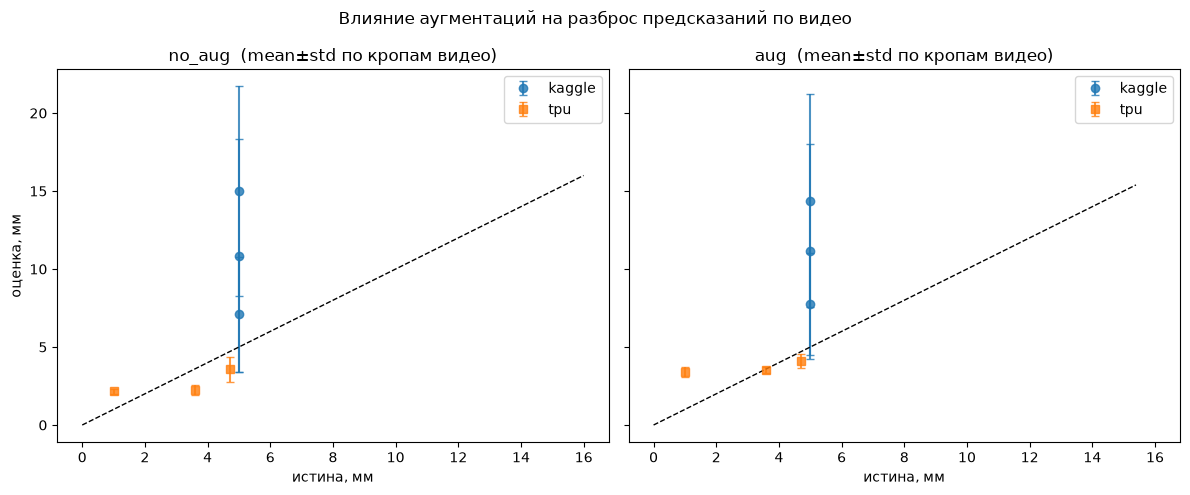

In [14]:
# per-video разброс предсказаний: сравнить error-bar'ы (std по кропам видео) с/без ауг
import pandas as pd
def per_video(res):
    rm = res["metrics"]
    df = pd.DataFrame({"vid":[r[0] for r in test_idx], "domain":[r[4] for r in test_idx],
                       "true":rm.y_true, "pred":rm.y_pred})
    return df.groupby(["domain","vid"]).agg(true=("true","first"),
            pred_mean=("pred","mean"), pred_std=("pred","std")).reset_index()

fig, axs = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)
for ax, key in zip(axs, ["no_aug","aug"]):
    g = per_video(cmp_aug[key])
    for d, mk in [("kaggle","o"), ("tpu","s")]:
        s = g[g.domain==d]
        ax.errorbar(s.true, s.pred_mean, yerr=s.pred_std, fmt=mk, capsize=3, alpha=.8, label=d)
    hi = max(g.true.max(), g.pred_mean.max())+1
    ax.plot([0,hi],[0,hi],"k--",lw=1)
    ax.set_title(f"{key}  (mean±std по кропам видео)"); ax.set_xlabel("истина, мм"); ax.legend()
axs[0].set_ylabel("оценка, мм")
fig.suptitle("Влияние аугментаций на разброс предсказаний по видео"); plt.tight_layout(); plt.show()

## Экспериментальная сетка (Muon)

`{convnext_nano, resnet34} × {p5, p5+d1} × {30, 50 эпох}` — 8 конфигураций,
оптимизатор только **Muon**. Сетап — смешанный трейн Эксп.2 (`train_idx`/`test_idx`),
метрики раздельно по доменам. Тяжёлый прогон: 8 обучений timm-сетей.

In [ ]:
import pandas as pd, itertools
CFG.optim.name = "muon"

grid = list(itertools.product(
    ["convnext_nano", "resnet34"],      # модель
    [Modes.p5, Modes.p5_d1],            # каналы
    [30, 50],                          # эпох
))

grid_rows, grid_metrics = [], {}
for model_name, mode, ep in grid:
    CFG.model.name = model_name
    CFG.train.epochs = ep
    key = f"{model_name}|{mode.value}|{ep}ep"
    print(f"\n########## {key} ##########")
    res = M.run(train_idx, test_idx, mode=mode, tag=f"grid_{key}", device=device)
    grid_metrics[key] = res["metrics"]
    for dom, m in res["metrics"].by_domain().items():
        grid_rows.append({"model": model_name, "mode": mode.value, "epochs": ep,
                          "domain": dom, **{k: round(v, 3) for k, v in m.items()}})

grid_df = pd.DataFrame(grid_rows)

In [ ]:
# сводка: по конфигу и домену (ключевые метрики)
tbl = (grid_df.set_index(["model","mode","epochs","domain"])
              [["mae_mm","rmse_mm","r2"]])
tbl

In [ ]:
# лучшие по tpu MAE (основная метрика на непокрытом диапазоне)
(grid_df[grid_df.domain=="tpu"]
   .sort_values("mae_mm")[["model","mode","epochs","mae_mm","rmse_mm"]]
   .reset_index(drop=True))

In [ ]:
# pred/true по всем 8 конфигурациям
n = len(grid_metrics); ncol = 4; nrow = (n + ncol - 1)//ncol
fig, axs = plt.subplots(nrow, ncol, figsize=(4*ncol, 4*nrow))
axs = np.atleast_1d(axs).ravel()
colors = {"kaggle": "tab:blue", "tpu": "tab:orange"}
for ax, (key, rm) in zip(axs, grid_metrics.items()):
    dom = np.array([r[4] for r in test_idx])
    for d in ["kaggle","tpu"]:
        mmask = dom==d
        ax.scatter(rm.y_true[mmask], rm.y_pred[mmask], s=14, alpha=.6,
                   color=colors[d], label=d)
    lo, hi = 0, max(rm.y_true.max(), rm.y_pred.max())+1
    ax.plot([lo,hi],[lo,hi],"k--",lw=1)
    mm = rm.compute()
    ax.set_title(f"{key}\nMAE={mm['mae_mm']:.2f} мм", fontsize=8)
    ax.set_xlabel("истина, мм"); ax.set_ylabel("pred, мм")
    ax.legend(fontsize=7)
for ax in axs[n:]:
    ax.axis("off")
fig.suptitle("Экспериментальная сетка (Muon) — pred vs true", y=1.01)
plt.tight_layout(); plt.show()

## Выводы

- **Эксп.1 (перенос):** MAE на tpu отражает экстраполяцию вниз по шкале — базовая
  оценка «в лоб», без tpu в трейне.
- **Эксп.2 (смесь):** добавление tpu-видео в трейн закрывает диапазон 0.5–25 мм;
  сравни tpu-MAE с Эксп.1 — падение = выигрыш от покрытия. kaggle-MAE показывает,
  что смешение не ломает «глубокую» зону.
- **Раздельные метрики** не дают домену с бо́льшим числом кропов задавить второй.
- k-fold по tpu даёт устойчивую оценку (±) вместо одиночного шумного теста.

Дальше: вариант C (μ,σ) для доверия на инференсе; подмена GT-маски на маску от
модели сегментации при разборе сырого видео.

## Оценённые глубины на тесте

Предсказания модели Эксп.2 (`out2`) по каждому тестовому кропу и агрегировано по
видео (у tpu все дефекты видео на одной глубине → сравниваем среднее предсказание
с истиной).

In [15]:
import pandas as pd
rm = out2["metrics"]                       # y_true/y_pred в порядке test_idx (shuffle=False)
df = pd.DataFrame({
    "vid":      [r[0] for r in test_idx],
    "domain":   [r[4] for r in test_idx],
    "true_mm":  np.round(rm.y_true, 2),
    "pred_mm":  np.round(rm.y_pred, 2),
})
df["err_mm"] = np.round(df.pred_mm - df.true_mm, 2)
print("=== по кропам ===")
df

=== по кропам ===


,vid,domain,true_mm,pred_mm,err_mm
0,R_020,kaggle,5.0,4.13,-0.87
1,R_020,kaggle,10.0,9.21,-0.79
2,R_020,kaggle,10.0,10.85,0.85
3,R_020,kaggle,20.0,16.47,-3.53
4,R_020,kaggle,20.0,21.59,1.59
5,R_020,kaggle,20.0,20.92,0.92
6,Z_004,kaggle,5.0,5.06,0.06
7,Z_004,kaggle,5.0,5.82,0.82
8,Z_004,kaggle,5.0,4.64,-0.36
9,Z_004,kaggle,5.0,4.76,-0.24


In [16]:
# агрегировано по видео: истина, среднее предсказание, разброс, ошибка
g = (df.groupby(["domain","vid"])
       .agg(true_mm=("true_mm","first"),
            pred_mm_mean=("pred_mm","mean"),
            pred_mm_std=("pred_mm","std"),
            n=("pred_mm","size"))
       .reset_index())
g["pred_mm_mean"] = g.pred_mm_mean.round(2)
g["pred_mm_std"]  = g.pred_mm_std.round(2)
g["err_mm"]       = (g.pred_mm_mean - g.true_mm).round(2)
print("=== по видео (агрегировано) ===")
g.sort_values(["domain","true_mm"])

=== по видео (агрегировано) ===


,domain,vid,true_mm,pred_mm_mean,pred_mm_std,n,err_mm
0,kaggle,R_020,5.0,13.86,6.95,6,8.86
1,kaggle,Z_004,5.0,10.24,6.85,12,5.24
2,kaggle,Z_011,5.0,7.26,3.51,2,2.26
3,tpu,Sample_3_Static,1.0,2.68,0.23,8,1.68
4,tpu,Sample_4_Static,3.6,2.90,0.46,8,-0.70
5,tpu,Sample_8_Static,4.7,3.61,0.16,8,-1.09


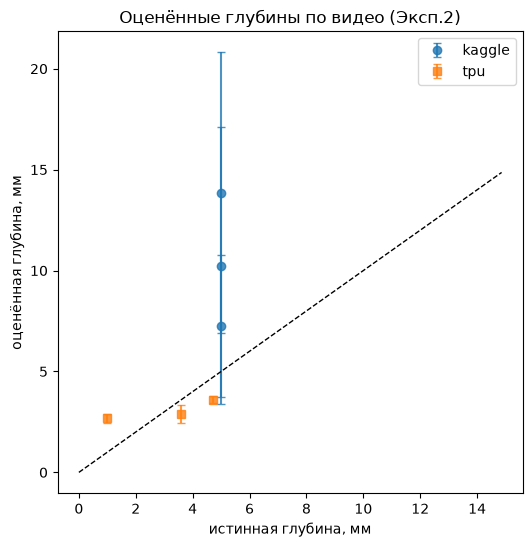

In [17]:
# истина vs предсказание по видео
fig, ax = plt.subplots(figsize=(6,6))
for d, mk in [("kaggle","o"), ("tpu","s")]:
    s = g[g.domain==d]
    ax.errorbar(s.true_mm, s.pred_mm_mean, yerr=s.pred_mm_std, fmt=mk,
                capsize=3, label=d, alpha=.8)
lo, hi = 0, max(g.true_mm.max(), g.pred_mm_mean.max())+1
ax.plot([lo,hi],[lo,hi],"k--",lw=1)
ax.set_xlabel("истинная глубина, мм"); ax.set_ylabel("оценённая глубина, мм")
ax.set_title("Оценённые глубины по видео (Эксп.2)"); ax.legend(); plt.show()